<a href="https://colab.research.google.com/github/sahithikaja/customer_segmentation/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving customer segmentation dataset.csv to customer segmentation dataset.csv


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("customer segmentation dataset.csv")
print("Original shape: ",df.shape)
df.head()

Original shape:  (2000, 7)


,CustomerID,Age,Gender,Annual_Income_k$,Spending_Score,Visits_Per_Month,Average_Purchase_Value
0,1,56,Male,83,84,2,99.65
1,2,69,Female,62,44,4,159.81
2,3,46,Female,34,87,10,245.59
3,4,32,Male,115,96,7,333.73
4,5,60,Female,82,75,17,266.38


In [3]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Annual_Income_k$,0
Spending_Score,0
Visits_Per_Month,0
Average_Purchase_Value,0


In [4]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in num_cols:
  df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
  df[col] = df[col].fillna(df[col].mode()[0])
print("Missing values handled safely")

Missing values handled safely


In [5]:
df = df.drop_duplicates()
print("After duplicate removal: ", df.shape)

After duplicate removal:  (2000, 7)


In [6]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)


print("After outlier removal:", df.shape)

After outlier removal: (2000, 7)


In [7]:
cat_cols = df.select_dtypes(include=['object']).columns

if len(cat_cols) > 0:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print("Encoding done")
else:
    print("No categorical columns left to encode")

Encoding done


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select only numerical columns
scale_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Scaling completed")

Scaling completed


In [9]:
df_reduced = df.sample(n=500, random_state=42)

print("Original shape:", df.shape)

Original shape: (2000, 7)


In [10]:
print("feature shape", df.shape)

feature shape (2000, 7)


In [11]:
print(df.columns)

Index(['CustomerID', 'Age', 'Annual_Income_k$', 'Spending_Score',
       'Visits_Per_Month', 'Average_Purchase_Value', 'Gender_Male'],
      dtype='object')


In [12]:
X = df[['Annual_Income_k$', 'Spending_Score']]

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.cluster import KMeans

In [15]:
import matplotlib.pyplot as plt

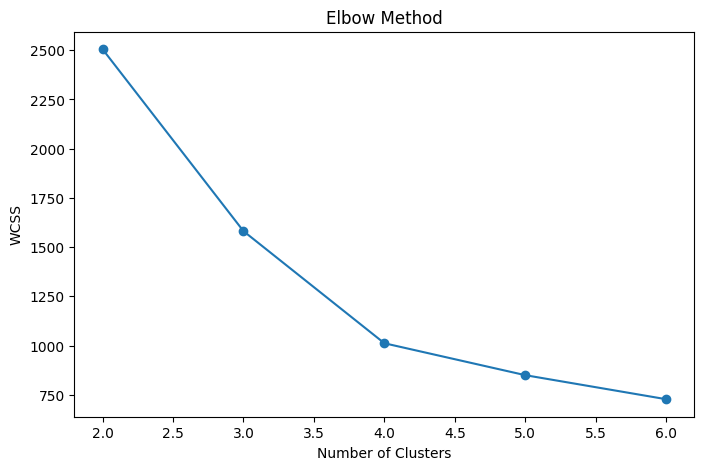

In [16]:
wcss = []

for i in range(2 , 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(2, 7), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster column to dataset
df['Cluster'] = clusters

print(df.head())

   CustomerID       Age  Annual_Income_k$  Spending_Score  Visits_Per_Month  \
0   -1.731185  0.817026         -0.001680        1.179778         -1.460660   
1   -1.729453  1.688020         -0.548553       -0.227316         -1.093821   
2   -1.727721  0.147031         -1.277718        1.285310          0.006695   
3   -1.725989 -0.790963          0.831651        1.601906         -0.543563   
4   -1.724257  1.085024         -0.027721        0.863182          1.290630   

   Average_Purchase_Value  Gender_Male  Cluster  
0               -1.090210         True        0  
1               -0.672022        False        3  
2               -0.075741        False        0  
3                0.536944         True        2  
4                0.068776        False        0  


In [18]:
print(df['Cluster'].value_counts())

Cluster
2    532
3    522
0    476
1    470
Name: count, dtype: int64


In [19]:
cluster_means = df.groupby('Cluster').mean()
print(cluster_means)


         CustomerID       Age  Annual_Income_k$  Spending_Score  \
Cluster                                                           
0         -0.050513  0.034989         -0.849180        0.921047   
1         -0.037375 -0.028736          0.826775       -0.913124   
2          0.084369  0.027892          0.893133        0.797786   
3         -0.006271 -0.034459         -0.880309       -0.830789   

         Visits_Per_Month  Average_Purchase_Value  Gender_Male  
Cluster                                                         
0               -0.045711                0.070639     0.495798  
1               -0.040136               -0.017702     0.476596  
2                0.067375                0.002445     0.471805  
3                0.009154               -0.050967     0.469349  


In [20]:
import seaborn as sns

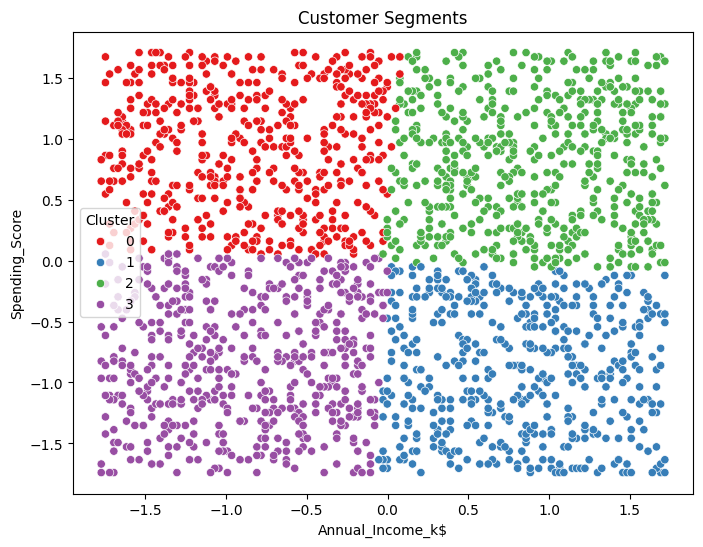

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Annual_Income_k$'],
                y=df['Spending_Score'],
                hue=df['Cluster'],
                palette='Set1')

plt.title('Customer Segments')
plt.xlabel('Annual_Income_k$')
plt.ylabel('Spending_Score')
plt.show()

In [22]:
df.to_csv("Customer_Segmentation_Preprocessed.csv", index=False)

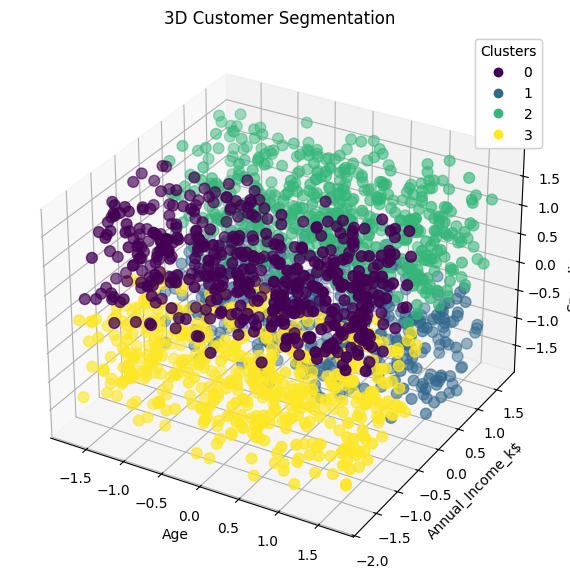

In [23]:
# Import 3D plotting toolkit
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Create figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    df['Age'],
    df['Annual_Income_k$'],
    df['Spending_Score'],
    c=df['Cluster'],          # Color based on cluster
    cmap='viridis',
    s=60
)

# Labels
ax.set_xlabel('Age')
ax.set_ylabel('Annual_Income_k$')
ax.set_zlabel('Spending_Score')

# Title
ax.set_title('3D Customer Segmentation')

# Add legend
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

# Show plot
plt.show()

In [24]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.40332712656195097
